# Parte 1
## White Patch Algorithm

1. Implementar el algoritmo White Patch para librarnos de las diferencias de color de iluminacion.
2. Mostrar los resultados obtenidos y analizar las posibles fallas (si es que las hay) en el caso de White patch.

In [2]:
import cv2 as cv
import numpy as np
import matplotlib.pyplot as plt
import os

# Configurar matplotlib para mostrar imágenes correctamente
plt.rcParams['figure.figsize'] = (15, 10)

## Funcion White Patch

El algoritmo White-Patch corrige el balance de blancos asumiendo que el píxel más brillante de cada canal RGB debería corresponder al blanco, y luego escala cada canal para compensar la iluminación de la escena. En términos prácticos, divide cada canal por su máximo o por un percentil alto para reducir el efecto de dominantes de color.

In [43]:
def white_patch(image, normalize=True):
    # Convierte la imagen a float32 para poder hacer operaciones matemáticas (como división) 
    # sin perder precisión ni saturar valores enteros.
    img = image.astype(np.float32)
    #print(f"Imagen convertida a float32: {img}")
    # Obtiene el maximo valor por canal para asumir como referencia de "blanco" en cada canal.
    ref = np.max(img, axis=(0, 1))
    min = np.min(img, axis=(0, 1))
    print(f"Valores de maximos: {ref} - Valores de minimos: {min}")
    # Reemplaza cualquier canal cuyo valor de referencia sea 0 por 1.0, para evitar división por cero en el paso siguiente.
    ref[ref == 0] = 1.0

    # Normaliza cada píxel dividiéndolo por el valor de referencia de su canal.
    # Escala de nuevo a rango de 8 bits (0–255) y convierte a uint8, que es el formato habitual de imágenes para mostrar o guardar.
    corrected = (img - min) * 255 / (ref - min) if normalize else img * 255 / ref

    return corrected.astype(np.uint8)

## Funciones utiles

In [39]:
def procesar_imagenes(image_files):
    results = []
    
    for img_file in image_files:
        img_path = os.path.join(image_dir, img_file)
        
        # Cargar imagen
        original = cv.imread(img_path)
        
        if original is None:
            print(f"No se pudo cargar {img_file}")
            continue
        
        # Convertir BGR a RGB para matplotlib
        original_rgb = cv.cvtColor(original, cv.COLOR_BGR2RGB)
        
        # Aplicar White Patch
        print(f"Imagen original: {img_file}")
        corrected = white_patch(original, normalize=False)
        #print(f"Imagen corregida: {corrected}")
        corrected_rgb = cv.cvtColor(corrected, cv.COLOR_BGR2RGB)
        
        normalized = white_patch(original, normalize=True)
        #print(f"Imagen corregida: {corrected}")
        normalized_rgb = cv.cvtColor(normalized, cv.COLOR_BGR2RGB)

        results.append({
            'name': img_file,
            'original': original_rgb,
            'corrected': corrected_rgb,
            'normalized': normalized_rgb
        })
    return results

In [44]:
def mostrar_resultados(results):
    for i, result in enumerate(results):
        plt.figure(figsize=(15, 6))
        
        # Imagen original
        plt.subplot(1, 3, 1)
        plt.imshow(result['original'])
        plt.title(f"Original: {result['name']}")
        plt.axis('off')
        
        # Imagen corregida
        plt.subplot(1, 3, 2)
        plt.imshow(result['corrected'])
        plt.title(f"White Patch: {result['name']}")
        plt.axis('off')
        
        # Imagen normalizada
        plt.subplot(1, 3, 3)
        plt.imshow(result['normalized'])
        plt.title(f"Normalized: {result['name']}")
        plt.axis('off')
        
        plt.tight_layout()
        plt.show()

## Cargar y Procesar Imagenes

Cargamos todas las imágenes del directorio `/white_patch` y aplicamos el algoritmo.

In [41]:
# Directorio de imágenes
image_dir = 'white_patch'

# Listar imágenes en el directorio
image_files_png = [f for f in os.listdir(image_dir) if f.endswith(('.png'))]
print(f"Imagenes encontradas PNG: {image_files_png}")
image_files_jpg = [f for f in os.listdir(image_dir) if 
                   f.endswith(('.jpg'))]
print(f"Imagenes encontradas: {image_files_jpg}")

Imagenes encontradas PNG: ['test_blue.png', 'test_green.png', 'test_red.png', 'wp_green.png', 'wp_red.png']
Imagenes encontradas: ['wp_blue.jpg', 'wp_green2.jpg', 'wp_red2.jpg']


## Resultados percentil 100

Imagen original: test_blue.png
Valores de maximos: [200. 138. 165.] - Valores de minimos: [0. 0. 0.]
Valores de maximos: [200. 138. 165.] - Valores de minimos: [0. 0. 0.]
Imagen original: test_green.png
Valores de maximos: [171. 250. 210.] - Valores de minimos: [0. 0. 0.]
Valores de maximos: [171. 250. 210.] - Valores de minimos: [0. 0. 0.]
Imagen original: test_red.png
Valores de maximos: [175. 157. 247.] - Valores de minimos: [0. 0. 0.]
Valores de maximos: [175. 157. 247.] - Valores de minimos: [0. 0. 0.]
Imagen original: wp_green.png
Valores de maximos: [155. 252. 126.] - Valores de minimos: [ 0. 18.  0.]
Valores de maximos: [155. 252. 126.] - Valores de minimos: [ 0. 18.  0.]
Imagen original: wp_red.png
Valores de maximos: [122. 134. 255.] - Valores de minimos: [ 0.  0. 11.]
Valores de maximos: [122. 134. 255.] - Valores de minimos: [ 0.  0. 11.]


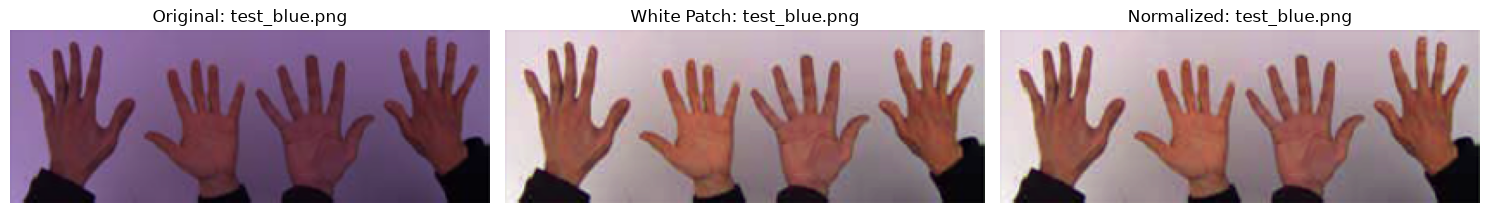

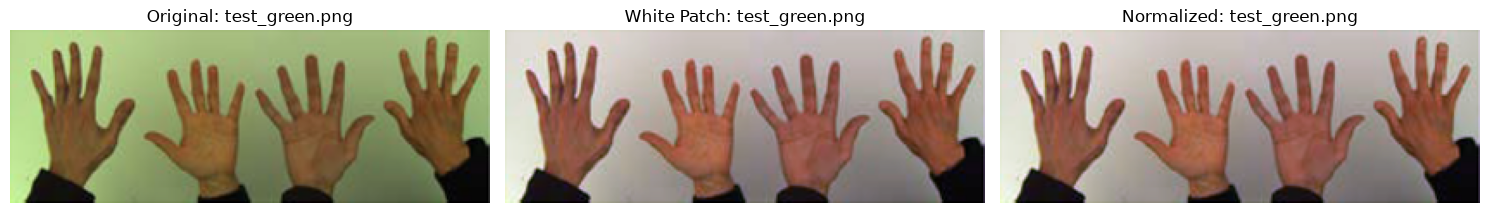

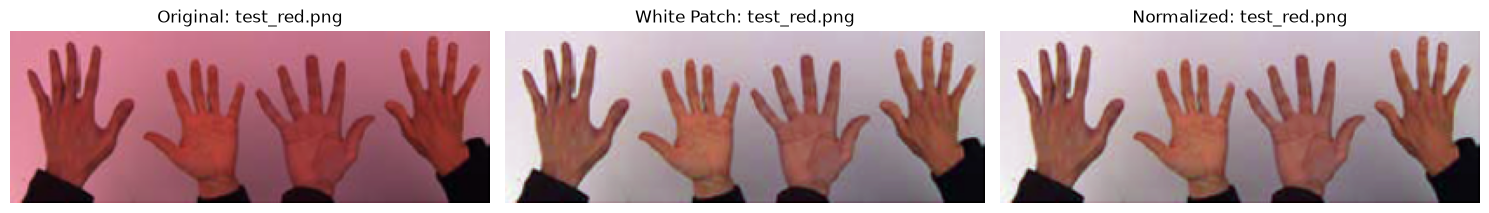

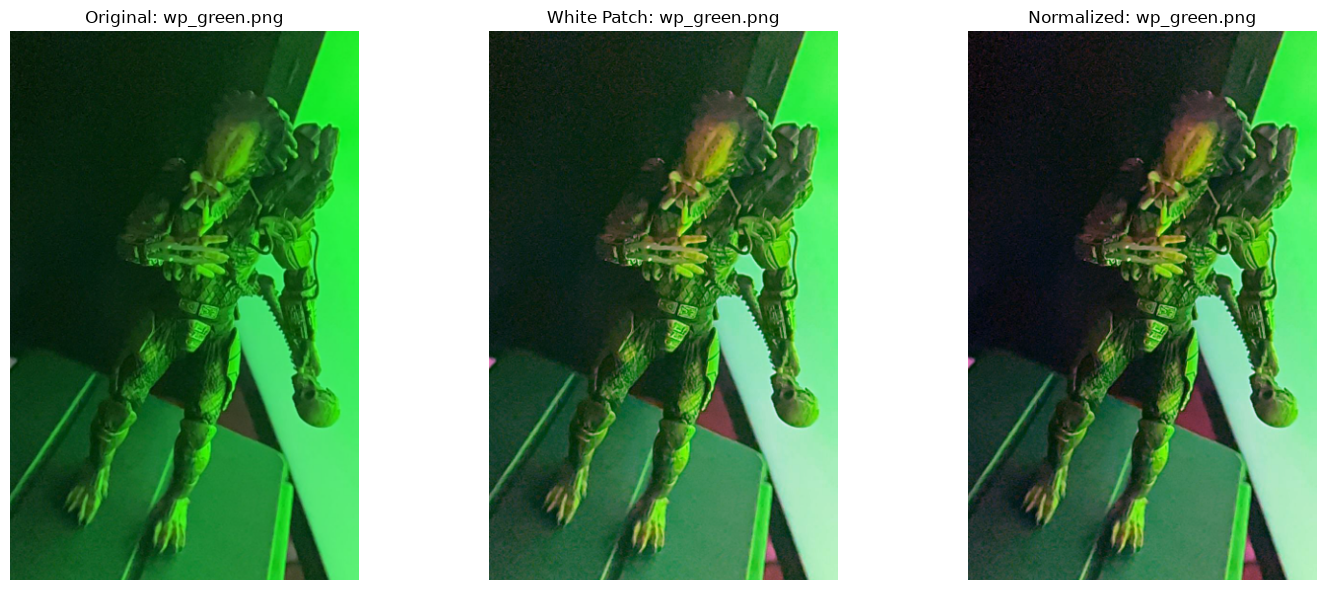

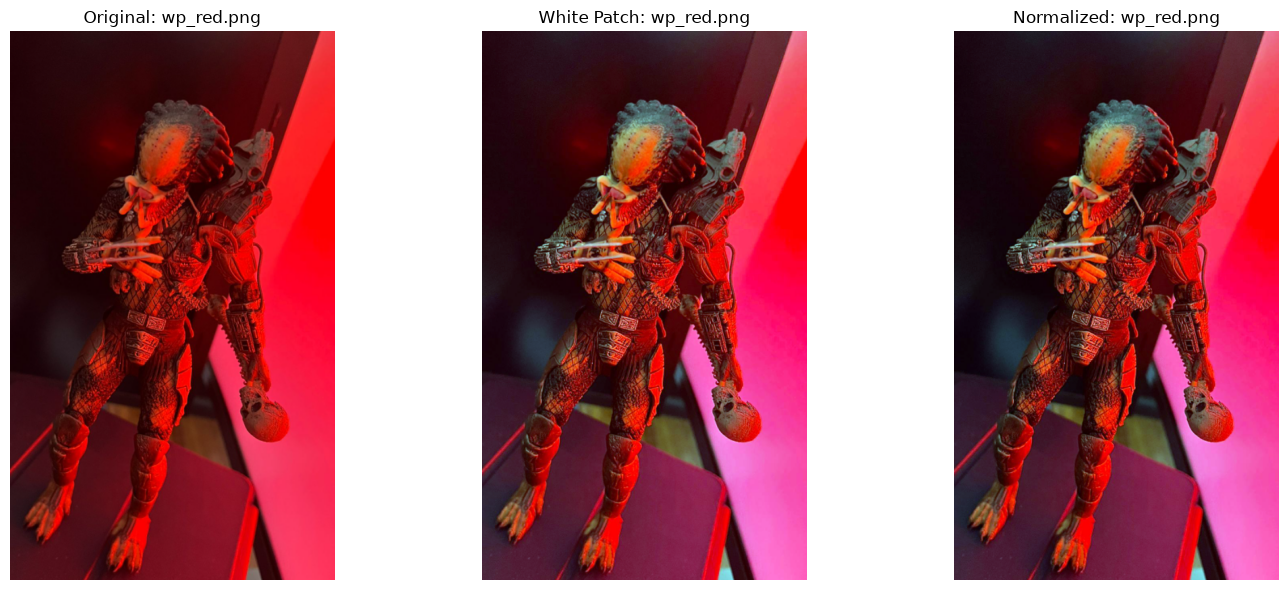

Imagen original: wp_blue.jpg
Valores de maximos: [255. 255. 255.] - Valores de minimos: [21.  0.  0.]
Valores de maximos: [255. 255. 255.] - Valores de minimos: [21.  0.  0.]
Imagen original: wp_green2.jpg
Valores de maximos: [172. 255. 170.] - Valores de minimos: [ 0. 22.  0.]
Valores de maximos: [172. 255. 170.] - Valores de minimos: [ 0. 22.  0.]
Imagen original: wp_red2.jpg
Valores de maximos: [203. 201. 255.] - Valores de minimos: [0. 0. 9.]
Valores de maximos: [203. 201. 255.] - Valores de minimos: [0. 0. 9.]


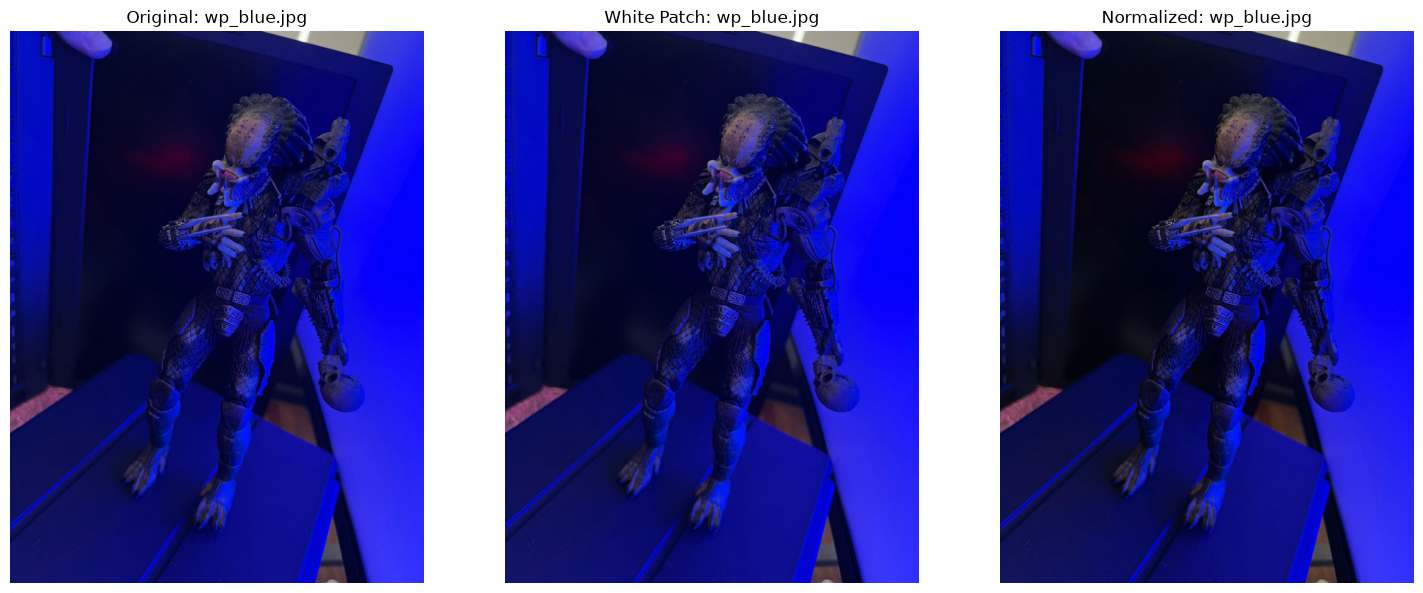

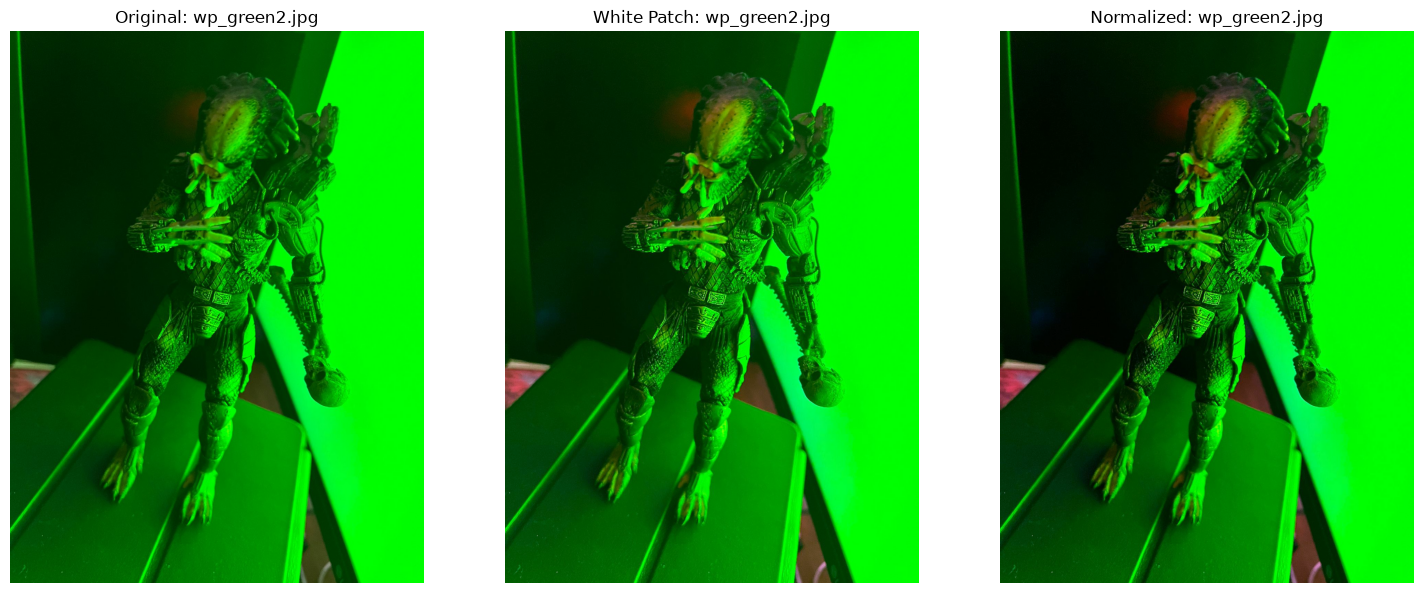

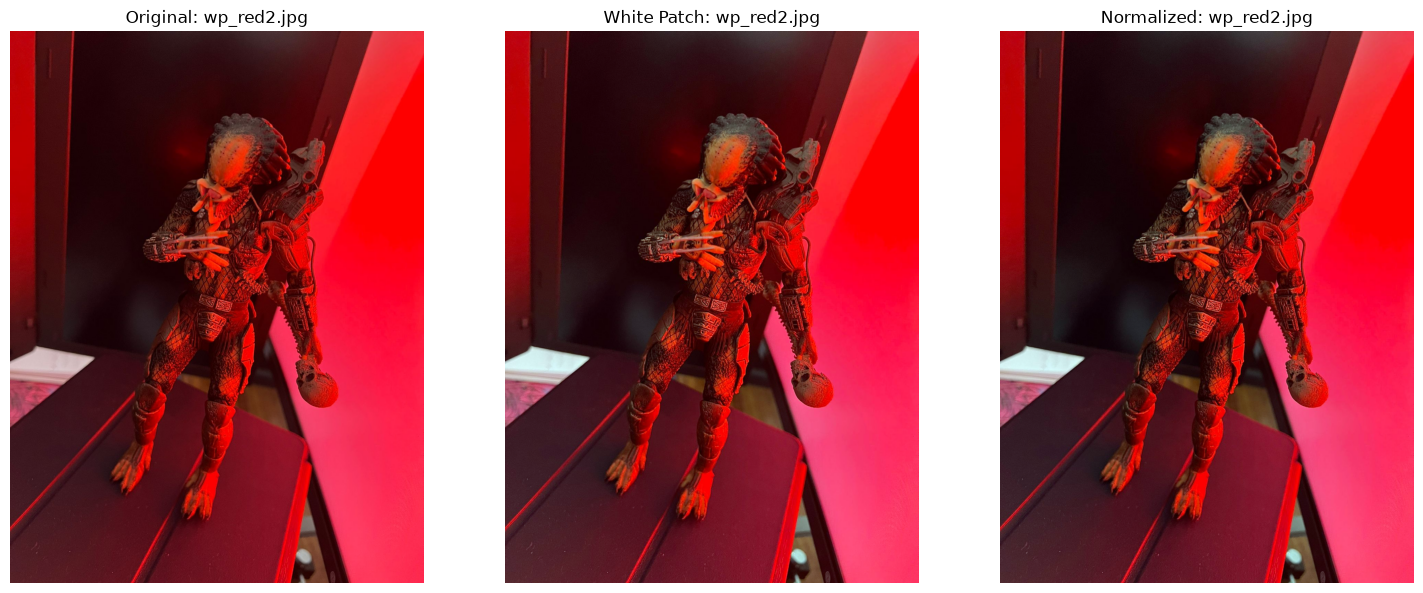

In [45]:
results = procesar_imagenes(image_files_png)
mostrar_resultados(results)

results = procesar_imagenes(image_files_jpg)
mostrar_resultados(results)

### Conclusión: 

Analizando las imagenes podemos observar que algunas poseen, no solo el maximo diferente a 255 (el rango maximo a considerar para normalizar), sino tambien el mínimo, no siempre corresponde al valor 0.

El error detectado en white patch creo que está en la normalización. El algoritmo asume que el valor mínimo es 0, pero al normalizar un rango también se tiene que considerar que el mínimo puede que no sea 0, sino un valor mayor. Por lo tanto el rango para normalizar de 0 a 255 debe ir desde el valor minimo al maximo de canal


## Parte 2: Análisis de histogramas para img1_tp.png y img2_tp.png

1. Para las imagenes img1_tp.png y im2_tp.png leerlas con OpenCV en escala de grises y visualizarlas.
2. Elija el numero de bins que crea conveniente y grafique su histograma, compare los histogramas entre si. Explicar lo que observar, si tuviera que entrenar un modelo de clasificacion/deteccion de imagenes, consideraria que puede ser de utilidar como feature a los histogramas?

### 1. Leer imágenes en escala de grises y visualizarlas

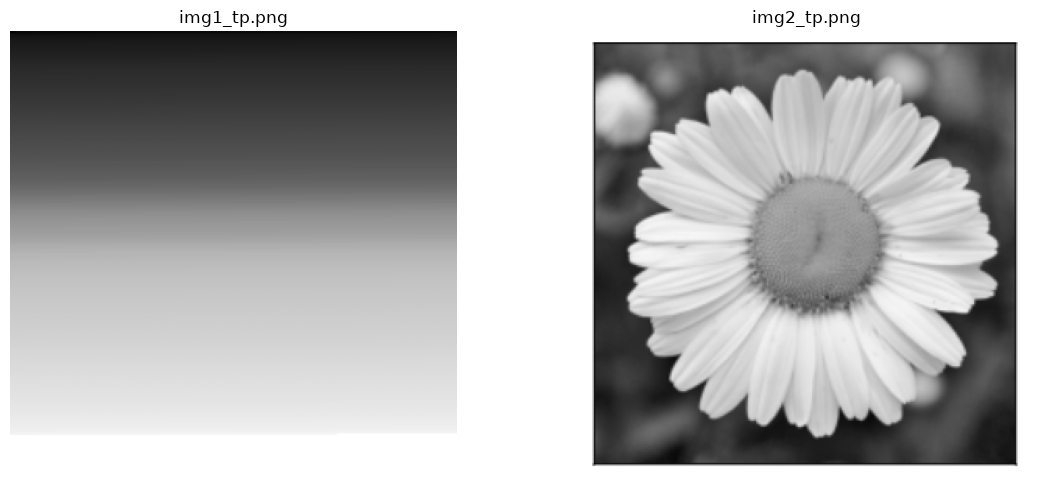

Dimensiones img1: (288, 287)
Dimensiones img2: (288, 287)


In [49]:
# Leer imágenes en escala de grises
img1 = cv.imread('img1_tp.png', cv.IMREAD_GRAYSCALE)
img2 = cv.imread('img2_tp.png', cv.IMREAD_GRAYSCALE)

# Visualizar las imágenes
plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
plt.imshow(img1, cmap='gray')
plt.title('img1_tp.png')
plt.axis('off')

plt.subplot(1, 2, 2)
plt.imshow(img2, cmap='gray')
plt.title('img2_tp.png')
plt.axis('off')

plt.tight_layout()
plt.show()

print(f"Dimensiones img1: {img1.shape}")
print(f"Dimensiones img2: {img2.shape}")

### 2. Histogramas de las imágenes

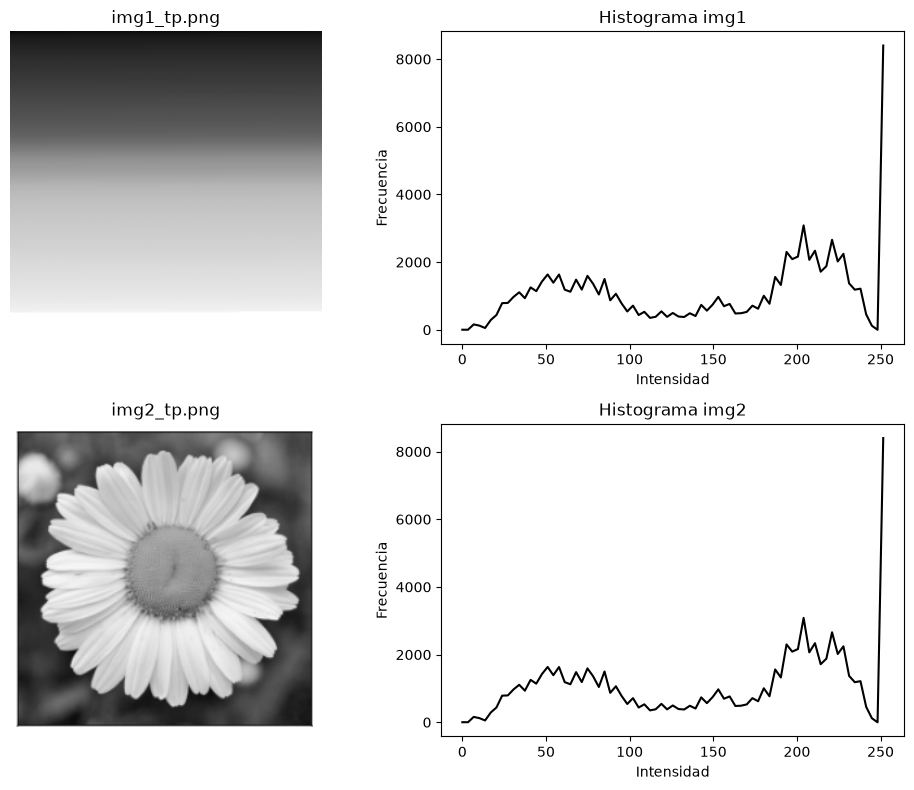

In [57]:
# Calcular histogramas con bins explícitos
hist1, bins1 = np.histogram(img1.ravel(), bins=75, range=(0, 255))
hist2, bins2 = np.histogram(img2.ravel(), bins=75, range=(0, 255))

fig = plt.figure(figsize=(10, 8))

# Imagen 1
ax1 = fig.add_subplot(2, 2, 1)
ax1.imshow(img1, cmap='gray', vmin=0, vmax=255)
ax1.set_title('img1_tp.png')
ax1.axis('off')

# Histograma 1
ax2 = fig.add_subplot(2, 2, 2)
ax2.plot(bins1[:-1], hist1, color='black')  # usás bins1 en el eje X
ax2.set_title('Histograma img1')
ax2.set_xlabel('Intensidad')
ax2.set_ylabel('Frecuencia')

# Imagen 2
ax3 = fig.add_subplot(2, 2, 3)
ax3.imshow(img2, cmap='gray', vmin=0, vmax=255)
ax3.set_title('img2_tp.png')
ax3.axis('off')

# Histograma 2
ax4 = fig.add_subplot(2, 2, 4)
ax4.plot(bins2[:-1], hist2, color='black')  # usás bins2 en el eje X
ax4.set_title('Histograma img2')
ax4.set_xlabel('Intensidad')
ax4.set_ylabel('Frecuencia')

plt.tight_layout()
plt.show()

## Conclusión:

Considerando que son 2 imágenes distintas, se puede observar que ambos histogramas son iguales o casi iguales, no hay diferencias.
Por lo tanto, no seria conveniente tomar los hitogramas como feature de referencia para un modelo de clasificacion de imagenes.